In [1]:
%autosave 60

Autosaving every 60 seconds


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, precision_recall_curve, precision_score, auc
from sklearn.preprocessing import label_binarize

# metrics

## 1) roc-auc

In [4]:
y_true = np.array([0, 0, 1, 1, 0, 1, 0, 1, 0, 1])
y_scores = np.array([0.1, 0.4, 0.35, 0.8, 0.2, 0.9, 0.3, 0.7, 0.5, 0.6])

In [5]:
indices = np.argsort(y_scores)[::-1]
y_true_sorted = y_true[indices]
y_scores_sorted = y_scores[indices]

In [40]:
n_positive = np.sum(y_true)
n_negative = len(y_true) - n_positive

tpr_values = []
fpr_values = []
thresholds = []

In [41]:
tp = 0
fp = 0

tpr_values.append(0)
fpr_values.append(0)
thresholds.append(y_scores_sorted[0] + 0.001)

In [42]:
for i in range(len(y_true_sorted)):
  if y_true_sorted[i] == 1:
    tp += 1
  else:
    fp += 1

  tpr = tp / n_positive
  fpr = fp / n_negative

  tpr_values.append(tpr)
  fpr_values.append(fpr)

  if i < len(y_true_sorted) - 1:
      thresholds.append(y_scores_sorted[i+1])
  else:
      thresholds.append(y_scores_sorted[i] - 0.001)

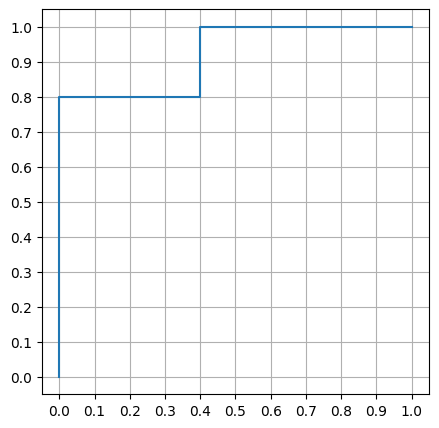

In [47]:
plt.figure(figsize=(5, 5))
plt.plot(fpr_values, tpr_values)
plt.yticks(np.arange(0, 1.01, 0.1))
plt.xticks(np.arange(0, 1.01, 0.1))
plt.grid()
# 0.92

In [44]:
auc = 0
for i in range(1, len(fpr_values)):
    width = fpr_values[i] - fpr_values[i-1]
    height = (tpr_values[i] + tpr_values[i-1]) / 2
    auc += width * height

    print(width, height, auc)

0.0 0.1 0.0
0.0 0.30000000000000004 0.0
0.0 0.5 0.0
0.0 0.7 0.0
0.2 0.8 0.16000000000000003
0.2 0.8 0.32000000000000006
0.0 0.9 0.32000000000000006
0.19999999999999996 1.0 0.52
0.20000000000000007 1.0 0.7200000000000001
0.19999999999999996 1.0 0.92


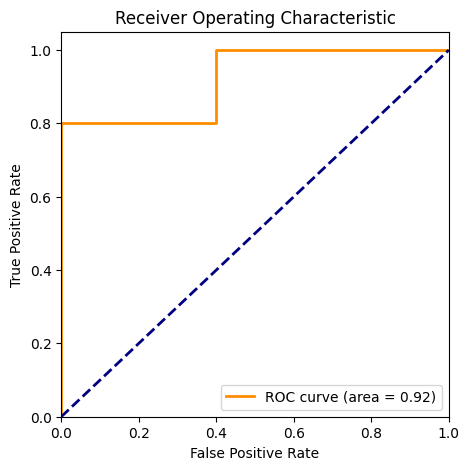

ROC AUC calculated from scratch: 0.9200
Thresholds: [0.901, 0.8, 0.7, 0.6, 0.5, 0.4, 0.35, 0.3, 0.2, 0.1, 0.099]
TPR values: [0, 0.2, 0.4, 0.6, 0.8, 0.8, 0.8, 1.0, 1.0, 1.0, 1.0]
FPR values: [0, 0.0, 0.0, 0.0, 0.0, 0.2, 0.4, 0.4, 0.6, 0.8, 1.0]


In [46]:

plt.figure(figsize=(5, 5))
plt.plot(fpr_values, tpr_values, color='darkorange', lw=2, label=f'ROC curve (area = {auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()

print(f"ROC AUC calculated from scratch: {auc:.4f}")
print(f"Thresholds: {thresholds}")
print(f"TPR values: {tpr_values}")
print(f"FPR values: {fpr_values}")


In [48]:
roc_auc_score(y_true, y_scores)

0.92

## 2) precision-recall curve

In [57]:
y_true = np.array([0, 0, 1, 1, 0, 1, 0, 1, 0, 1])
y_scores = np.array([0.1, 0.4, 0.35, 0.8, 0.2, 0.9, 0.3, 0.7, 0.5, 0.6])

In [51]:
indices = np.argsort(y_scores)[::-1]
y_true_sorted = y_true[indices]
y_scores_sorted = y_scores[indices]

In [52]:
n_positive = np.sum(y_true)
precision_values = []
recall_values = []
thresholds = []

In [53]:
tp = 0
fp = 0

precision_values.append(1.0)
recall_values.append(0.0)
thresholds.append(y_scores_sorted[0] + 0.001)


for i in range(len(y_true_sorted)):
    if y_true_sorted[i] == 1:
        tp += 1
    else:
        fp += 1


    if tp + fp > 0:
        precision = tp / (tp + fp) # !
    else:
        precision = 1.0

    recall = tp / n_positive # !

    precision_values.append(precision)
    recall_values.append(recall)


    if i < len(y_true_sorted) - 1:
        thresholds.append(y_scores_sorted[i+1])
    else:
        thresholds.append(y_scores_sorted[i] - 0.001)

In [54]:
ap = 0
for i in range(1, len(recall_values)):
    width = recall_values[i] - recall_values[i-1]
    height = (precision_values[i] + precision_values[i-1]) / 2
    ap += width * height

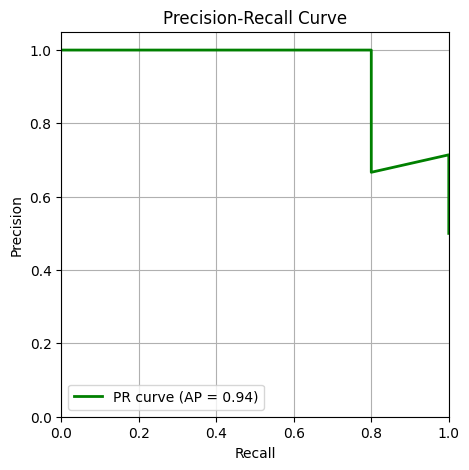

Average Precision calculated from scratch: 0.9381
Thresholds: [0.901, 0.8, 0.7, 0.6, 0.5, 0.4, 0.35, 0.3, 0.2, 0.1, 0.099]
Precision values: [1.0, 1.0, 1.0, 1.0, 1.0, 0.8, 0.6666666666666666, 0.7142857142857143, 0.625, 0.5555555555555556, 0.5]
Recall values: [0.0, 0.2, 0.4, 0.6, 0.8, 0.8, 0.8, 1.0, 1.0, 1.0, 1.0]


In [55]:
plt.figure(figsize=(5, 5))
plt.plot(recall_values, precision_values, color='green', lw=2, label=f'PR curve (AP = {ap:.2f})')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

print(f"Average Precision calculated from scratch: {ap:.4f}")
print(f"Thresholds: {thresholds}")
print(f"Precision values: {precision_values}")
print(f"Recall values: {recall_values}")

In [64]:
from sklearn.metrics import auc
precision, recall, _ = precision_recall_curve(y_true, y_scores)
auc(recall, precision)

0.9380952380952381

## 3) precision micro / precision macro
- average = micro
- average = macro


In [84]:
y_true = np.array([0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2])
y_pred = np.array([0, 1, 0, 0, 0, 2, 2, 1, 2, 0, 0, 2, 0, 1, 0])

In [85]:
classes = np.unique(y_true)
n_classes = len(classes)
class_precision = {}

tp = np.zeros(n_classes)
fp = np.zeros(n_classes)

In [86]:
for i, cls in enumerate(classes):
  tp[i] = np.sum((y_pred == cls) & (y_true == cls))
  fp[i] = np.sum((y_pred == cls) & (y_true != cls))

  if tp[i] + fp[i] > 0:
      class_precision[cls] = tp[i] / (tp[i] + fp[i])
  else:
      class_precision[cls] = 0.0

In [87]:
class_precision

{0: 0.5, 1: 1.0, 2: 0.75}

In [88]:
# Macro Precision
precision_macro = np.mean(list(class_precision.values()))
# на малочисленных классах влияет на общую оценку так же сильно, как и на многочисленных классах
# сильное влияние на ошибку у малых классов
print(f"precision_macro: {precision_macro}")

# Micro Precision
precision_micro = np.sum(tp) / (np.sum(tp) + np.sum(fp))
# более устойчивая если есть минорные классы (мало примеров в одном из классов)
print(f"precision_macro: {precision_micro}")

precision_macro: 0.75
precision_macro: 0.6666666666666666


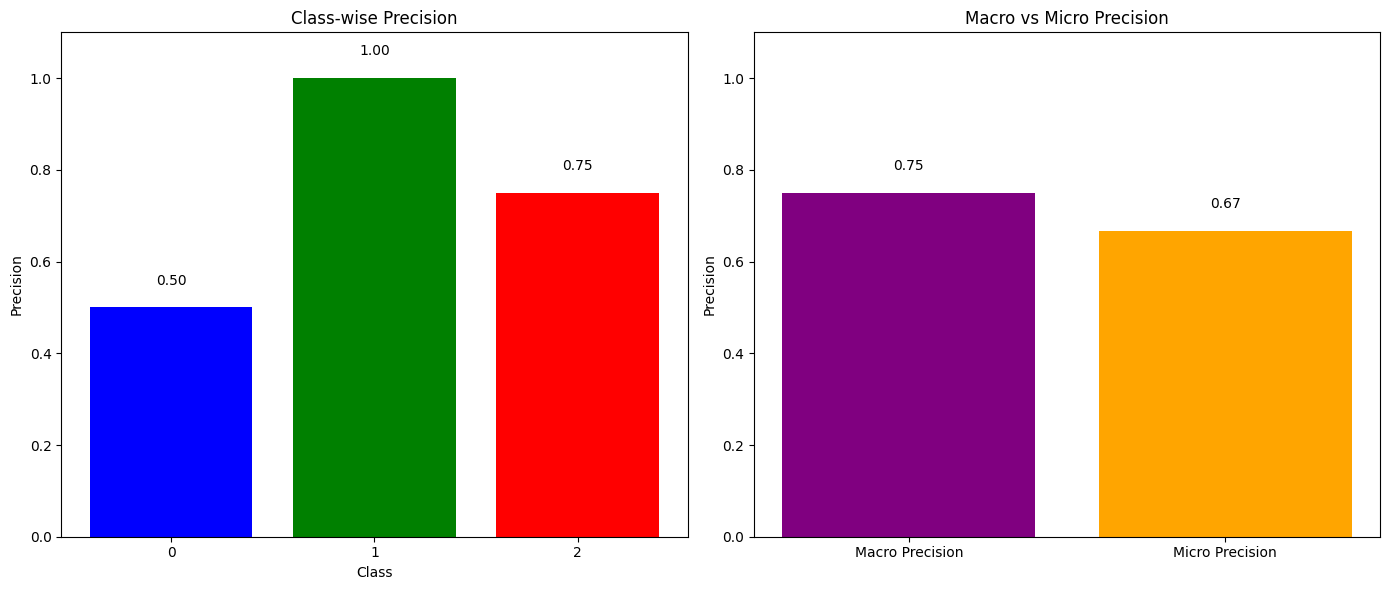

In [89]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Plot class-wise precision
ax[0].bar(list(class_precision.keys()), list(class_precision.values()), color=['blue', 'green', 'red'])
ax[0].set_xlabel('Class')
ax[0].set_ylabel('Precision')
ax[0].set_title('Class-wise Precision')
ax[0].set_ylim([0, 1.1])
ax[0].set_xticks(classes)
for i, cls in enumerate(classes):
    ax[0].text(cls, class_precision[cls] + 0.05, f'{class_precision[cls]:.2f}', ha='center')


ax[1].bar(['Macro Precision', 'Micro Precision'], [precision_macro, precision_micro], color=['purple', 'orange'])
ax[1].set_ylabel('Precision')
ax[1].set_title('Macro vs Micro Precision')
ax[1].set_ylim([0, 1.1])
ax[1].text(0, precision_macro + 0.05, f'{precision_macro:.2f}', ha='center')
ax[1].text(1, precision_micro + 0.05, f'{precision_micro:.2f}', ha='center')

plt.tight_layout()
plt.show()

In [90]:
print("Confusion Matrix:")
confusion_matrix = np.zeros((n_classes, n_classes))
for i in range(len(y_true)):
    confusion_matrix[y_true[i]][y_pred[i]] += 1
print(confusion_matrix)

print(f"Class-wise precision: {class_precision}")
print(f"Macro-averaged precision: {precision_macro:.4f}")
print(f"Micro-averaged precision: {precision_micro:.4f}")


Confusion Matrix:
[[4. 0. 1.]
 [2. 3. 0.]
 [2. 0. 3.]]
Class-wise precision: {0: 0.5, 1: 1.0, 2: 0.75}
Macro-averaged precision: 0.7500
Micro-averaged precision: 0.6667


In [91]:
precision_score(y_true, y_pred, average='macro'), precision_score(y_true, y_pred, average='micro')

(0.75, 0.6666666666666666)

# metrics correlation

In [92]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score
from sklearn.preprocessing import StandardScaler

In [93]:
def create_dataset(n_samples=500, n_features=5, noise=0.5, random_state=None):
    return make_regression(
        n_samples=n_samples, n_features=n_features,
        noise=noise, random_state=random_state
    )

In [94]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=50, random_state=42)
}

In [95]:
all_metrics = []

In [101]:
%%time
for seed in range(20):
  for noise_level in [0.5, 2.0, 5.0]:
    X, y = create_dataset(
        n_samples=500, n_features=5,
        noise=noise_level, random_state=seed
    )

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=seed
    )


    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train) # !
    X_test_scaled = scaler.transform(X_test) # !

    for model_name, model in models.items():
      model.fit(X_train_scaled, y_train)
      y_pred = model.predict(X_test_scaled)

      mse = mean_squared_error(y_test, y_pred)
      rmse = np.sqrt(mse)
      mae = mean_absolute_error(y_test, y_pred)
      r2 = r2_score(y_test, y_pred)
      evs = explained_variance_score(y_test, y_pred)

      all_metrics.append({
          'Model': model_name,
          'MSE': mse,
          'RMSE': rmse,
          'MAE': mae,
          'R2': r2,
          'EVS': evs,
          'Noise': noise_level
      })

CPU times: user 12.5 s, sys: 29.6 ms, total: 12.6 s
Wall time: 14.7 s


In [102]:
len(all_metrics)

270

In [103]:
metrics_df = pd.DataFrame(all_metrics)

In [104]:
metrics_df.head()

,Model,MSE,RMSE,MAE,R2,EVS,Noise
0,Linear Regression,0.238157,0.488013,0.389268,0.999969,0.999969,0.5
1,Ridge,0.275505,0.524886,0.428515,0.999964,0.999965,0.5
2,Random Forest,858.258202,29.296044,22.650741,0.888851,0.890137,0.5
3,Linear Regression,3.810512,1.952053,1.557070,0.999506,0.999507,2.0
4,Ridge,3.814310,1.953026,1.562380,0.999506,0.999507,2.0


In [105]:
correlation_matrix = metrics_df[['MSE', 'RMSE', 'MAE', 'R2', 'EVS']].corr()

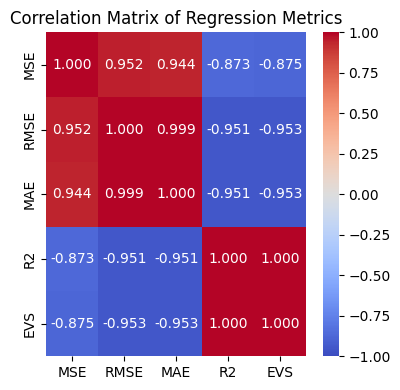

In [108]:
plt.figure(figsize=(4, 4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0, fmt='.3f')
plt.title('Correlation Matrix of Regression Metrics')
plt.tight_layout()
plt.show()

# loss functions

In [109]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.tree import DecisionTreeRegressor

In [110]:
from matplotlib import cm
rainbow_cmap = cm.get_cmap('gist_rainbow')

<ipython-input-110-f1fee69294c2>:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  rainbow_cmap = cm.get_cmap('gist_rainbow')


In [135]:
X = np.array(sorted(np.random.uniform(-4, 4, 200)))
y = np.sin(X) + np.random.normal(0, 0.1, 200)

F = np.zeros(len(X))

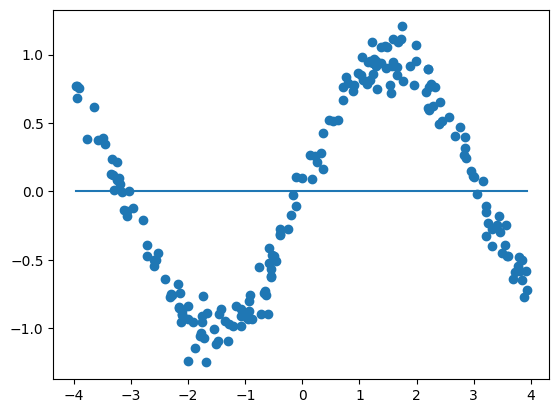

In [136]:
plt.scatter(X, y)
plt.plot(X, F)
plt.show()

In [147]:
preds = DecisionTreeRegressor(max_depth=5).fit(np.array((X)).reshape(-1, 1), y).predict(np.array((X)).reshape(-1, 1))

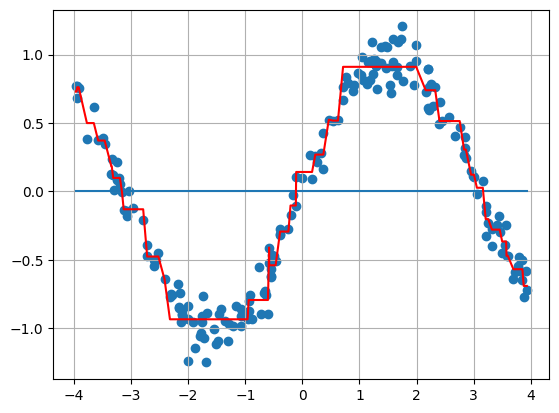

In [150]:
plt.scatter(X, y)
plt.plot(X, F)
plt.plot(X, preds, color='red')
plt.grid()
plt.show()

In [151]:
def loss_func(y_true, y_pred):
  loss = y_true - y_pred
  return np.where(loss > 0, np.log1p(loss), 0)

<ipython-input-151-26b632d7d704>:3: RuntimeWarning: invalid value encountered in log1p
  return np.where(loss > 0, np.log1p(loss), 0)


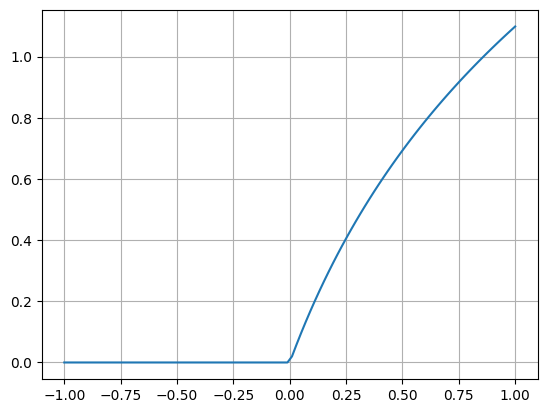

In [157]:
plt.plot(np.linspace(-1, 1, 100), loss_func(np.linspace(-1, 1, 100), np.linspace(1, -1, 100)))
plt.grid()
plt.show()

In [161]:
n_estimators = 100
learning_rate = 0.01

In [175]:
def custom_loss(y_pred, y_true):

  error = y_true - y_pred
  grad = np.where(error > 0, (error), error*0.1)
  hess = 0 * error + 2

  return grad, hess  # (первая производная, вторая производная)

In [176]:
from lightgbm import LGBMRegressor
from IPython.display import clear_output


model = LGBMRegressor(loss=custom_loss, verbose=0, n_estimators=250)

In [177]:
model = model.fit(X.reshape(-1, 1), y)
clear_output()

In [178]:
F = model.predict(X.reshape(-1, 1))

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/lightgbm/sklearn.py:737: UserWarning: Found 'loss' in params. Will use it instead of 'objective' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'objective' argument")


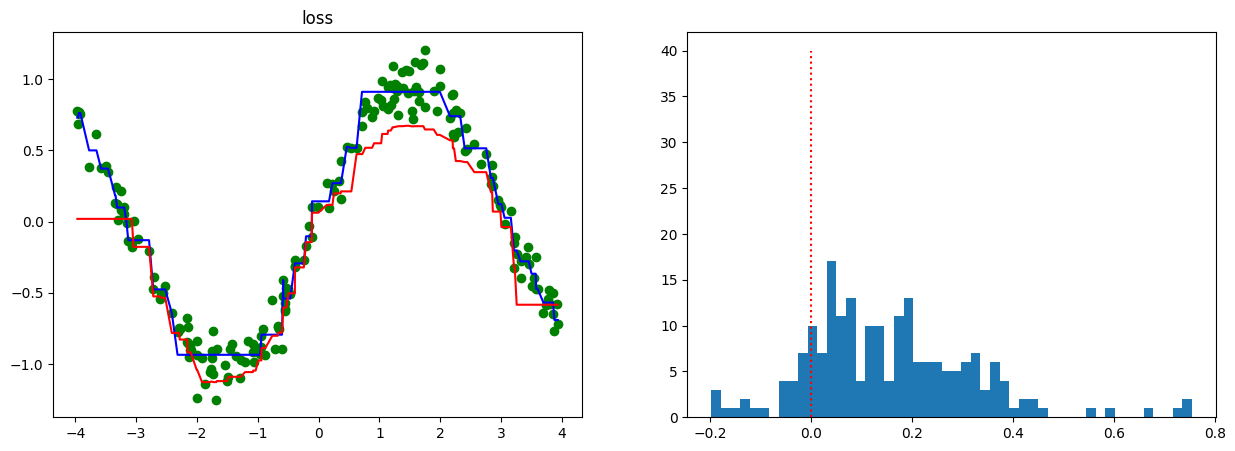

In [179]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.scatter(X, y, color='green')
plt.plot(X, preds, color='blue')
plt.plot(X, F, color='red')

plt.title('loss')

plt.subplot(1, 2, 2)
plt.hist(y - F, bins=50)
plt.vlines(0, 0, 40, color='r', linestyle=':')
plt.show()